# Week 1

In [24]:
# 라이브러리 import 및 버전 확인
import tensorflow as tf
import numpy as np
import pandas as pd

print("TensorFlow 버전:", tf.__version__)
print("NumPy 버전:", np.__version__)
print("Pandas 버전:", pd.__version__)


# 데이터 다운로드
path_to_train_file = tf.keras.utils.get_file('train.txt',
                                             'https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt')


path_to_test_file = tf.keras.utils.get_file('test.txt',
                                            'https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt')

TensorFlow 버전: 2.21.0
NumPy 버전: 2.4.4
Pandas 버전: 3.0.2


In [25]:
train_text = open(path_to_train_file, 'rb').read().decode(encoding='utf-8')
test_text = open(path_to_test_file, 'rb').read().decode(encoding='utf-8')

print(f'train text 길이: {len(train_text)} characters') 
print(f'test text 길이: {len(test_text)} characters')
print('test text의 처음 500자 출력:\n', test_text[:500]) 

train text 길이: 6937271 characters
test text 길이: 2318260 characters
test text의 처음 500자 출력:
 id	document	label
6270596	굳 ㅋ	1
9274899	GDNTOPCLASSINTHECLUB	0
8544678	뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아	0
6825595	지루하지는 않은데 완전 막장임... 돈주고 보기에는....	0
6723715	3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??	0
7898805	음악이 주가 된, 최고의 음악영화	1
6315043	진정한 쓰레기	0
6097171	마치 미국애니에서 튀어나온듯한 창의력없는 로봇디자인부터가,고개를 젖게한다	0
8932678	갈수록 개판되가는 중국영화 유치하고 내용없음 폼잡다 끝남 말도안되는 무기에 유치한cg남무 아 그립다 동사서독같은 영화가 이건 3류아류작이다	0
6242223	이별의 아픔뒤에 찾아오는 새로운 인연의 기쁨 But, 모든 사람이 그렇지는 않네..	1
7462111	괜찮네요오랜만포켓몬스터잼밌어요	1
8425305	한국독립영화의


In [26]:
#  Y(정답 라벨) 데이터 만들기
train_Y = np.array([
    [int(row.split('\t')[2])] # 3. 라벨 값 추출
    for row in train_text.split('\n')[1:] # 1. 첫 번째 줄(0) 제외, 한 줄씩 순회
    if row.count('\t') > 0 # 2. 탭 없는 줄 제외
])

test_Y = np.array([
    [int(row.split('\t')[2])]
    for row in test_text.split('\n')[1:]
    if row.count('\t') > 0
])

print("train_Y shape:", train_Y.shape)
print("test_Y shape:", test_Y.shape)
print("train_Y sample:", train_Y[:10])

train_Y shape: (150000, 1)
test_Y shape: (50000, 1)
train_Y sample: [[0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]]


In [27]:
import re

def clean_str(string): 
    string = re.sub(r"[^가-힣A-Za-z0-9(),!?\'\`]", " ", string) # 한글, 영어, 숫자, 일부 특수문자 제외한 모든 문자 제거
    string = re.sub(r"\'s", " \'s", string) # 
    string = re.sub(r"\'ve", " \'ve", string) 
    string = re.sub(r"n\'t", " n\'t", string)
    string = re.sub(r"\'re", " \'re", string)
    string = re.sub(r"\'d", " \'d", string)
    string = re.sub(r"\'ll", " \'ll", string)
    string = re.sub(r",", " , ", string)
    string = re.sub(r"!", " ! ", string)
    string = re.sub(r"\(", " \( ", string)
    string = re.sub(r"\)", " \) ", string) 
    string = re.sub(r"\?", " \? ", string)
    string = re.sub(r"\s{2,}", " ", string)
    string = re.sub(r"\'{2,}", "\'", string)
    string = re.sub(r"\'", "", string)

    return string.lower()

# 리뷰 텍스트만 추출 
train_text_X = [row.split('\t')[1] 
                for row in train_text.split('\n')[1:] 
                if row.count('\t') > 0]

#clean_str을 이용해 리뷰 텍스트 전처리
train_text_X = [clean_str(sentence) for sentence in train_text_X]

# 문장을 띄어쓰기 단위로 단어 분리
sentences = [sentence.split(' ') for sentence in train_text_X]


# 학습 데이터 10개 샘플 출력
for i in range(10):
    print(sentences[i])

['아', '더빙', '진짜', '짜증나네요', '목소리']
['흠', '포스터보고', '초딩영화줄', '오버연기조차', '가볍지', '않구나']
['너무재밓었다그래서보는것을추천한다']
['교도소', '이야기구먼', '솔직히', '재미는', '없다', '평점', '조정']
['사이몬페그의', '익살스런', '연기가', '돋보였던', '영화', '!', '스파이더맨에서', '늙어보이기만', '했던', '커스틴', '던스트가', '너무나도', '이뻐보였다']
['막', '걸음마', '뗀', '3세부터', '초등학교', '1학년생인', '8살용영화', '별반개도', '아까움', '']
['원작의', '긴장감을', '제대로', '살려내지못했다', '']
['별', '반개도', '아깝다', '욕나온다', '이응경', '길용우', '연기생활이몇년인지', '정말', '발로해도', '그것보단', '낫겟다', '납치', '감금만반복반복', '이드라마는', '가족도없다', '연기못하는사람만모엿네']
['액션이', '없는데도', '재미', '있는', '몇안되는', '영화']
['왜케', '평점이', '낮은건데', '\\?', '꽤', '볼만한데', '헐리우드식', '화려함에만', '너무', '길들여져', '있나', '\\?', '']


In [28]:
VOCAB_SIZE = 2000   # 단어 사전 크기
MAX_LEN = 25        # 최대 문장 길이 (패딩 기준)

#전처리 담당 레이어 정의
vectorize_layer = tf.keras.layers.TextVectorization(
    standardize='lower_and_strip_punctuation',  # 소문자 변환 + 구두점 제거
    split='whitespace',                         # 띄어쓰기 기준 토큰화
    max_tokens=VOCAB_SIZE,                      # 단어 사전 크기
    output_mode='int',                          # 정수 인코딩
    output_sequence_length=MAX_LEN              # 자동 패딩
)

# 텍스트로 단어 사전 구축 (단어:정수 매핑)
vectorize_layer.adapt(train_text_X)

# 단어 사전을 이용해 텍스트 데이터를 정수 시퀀스로 변환
train_X = vectorize_layer(train_text_X)

print(train_X[0])

print(train_X[:5])

tf.Tensor(
[  23  902    5    1 1097    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0], shape=(25,), dtype=int64)
tf.Tensor(
[[  23  902    5    1 1097    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0]
 [ 586    1    1    1    1    1    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0]
 [   1    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0]
 [   1    1   68  345   28   33    1    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0]
 [   1    1  102    1    2    1    1  844    1    1  570    1    0    0
     0    0    0    0    0    0    0    0    0    0    0]], shape=(5, 25), dtype=int64)


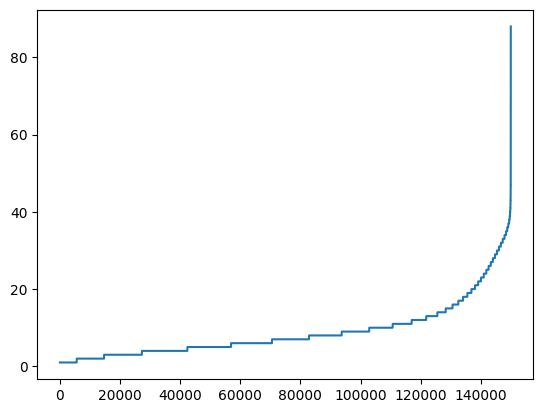

In [29]:
import matplotlib.pyplot as plt
sentence_len = [len(sentence) for sentence in sentences] # 각 문장의 단어 수 계산
sentence_len.sort() # 단어 수 기준 정렬
plt.plot(sentence_len)
plt.show()

In [30]:
print(sum([int(l<=25) for l in sentence_len]))

142587


# week 2

In [31]:
test_text_X = [
    row.split('\t')[1]
    for row in test_text.split('\n')[1:]
    if row.count('\t') > 0
]

# Week1에서 학습된 vectorize_layer 그대로 사용합니다.
test_X = vectorize_layer(test_text_X)

print("test_X shape:", test_X.shape)
print("test_Y shape:", test_Y.shape)

test_X shape: (50000, 25)
test_Y shape: (50000, 1)


In [32]:
# 하이퍼파라미터 설정
VOCAB_SIZE = 2000
EMBEDDING_DIM = 128
MAX_LEN = 25
EPOCHS = 10
BATCH_SIZE = 32

# model 정의 
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_shape=(MAX_LEN,)), #입력층
    tf.keras.layers.GlobalAveragePooling1D(), #은닉층
    tf.keras.layers.Dense(64, activation='relu'), #은닉층
    tf.keras.layers.Dense(1, activation='sigmoid') #출력층
])
model.summary()

#현재 가중치 확인
model.get_weights()  


/opt/miniconda3/envs/gdg/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 25, 128)        │       256,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,321 (1.01 MB)

 Trainable params: 264,321 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

[array([[-0.02985241, -0.03654095, -0.0293412 , ..., -0.01020171,
         -0.04156021,  0.03271767],
        [ 0.00611218,  0.01826474,  0.04044104, ..., -0.01139494,
          0.04594866, -0.03355037],
        [ 0.01760772, -0.00287315,  0.01029197, ...,  0.02788423,
          0.04900796,  0.01467228],
        ...,
        [ 0.0114759 , -0.0441516 , -0.03186703, ...,  0.02392453,
          0.01821916,  0.00792615],
        [-0.00328543, -0.04395585, -0.01885562, ...,  0.02438066,
         -0.00382482,  0.00169001],
        [-0.01344591,  0.00405423,  0.01592969, ..., -0.01462384,
          0.03441873, -0.00615595]], shape=(2000, 128), dtype=float32),
 array([[-0.14659213,  0.16930436,  0.10695641, ...,  0.126557  ,
          0.1327024 ,  0.15339585],
        [ 0.02355205, -0.13872615, -0.074896  , ..., -0.11284763,
          0.01586403, -0.1447965 ],
        [-0.08610125, -0.14992645,  0.07539202, ..., -0.12793212,
         -0.09352323, -0.14689972],
        ...,
        [-0.13207929

### model.fit() (Keras)

- 프레임워크: TensorFlow/Keras 기반
- 추상화 수준: 중간
- 커스터마이징: 파라미터 직접 전달

- TensorFlow/Keras 모델에 사용
- 간단하고 직관적
- callbacks으로 확장?

- Trainer → PyTorch + Transformer 모델을 위한 올인원 학습 루프
- model.fit() → Keras 모델의 기본 학습 메서드

In [33]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 모델 학습
history = model.fit(
    train_X, train_Y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

model.summary()
model.get_weights()  


Epoch 1/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7221 - loss: 0.5082 - val_accuracy: 0.7584 - val_loss: 0.4612
Epoch 2/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7494 - loss: 0.4647 - val_accuracy: 0.7583 - val_loss: 0.4596
Epoch 3/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7540 - loss: 0.4573 - val_accuracy: 0.7558 - val_loss: 0.4597
Epoch 4/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7547 - loss: 0.4533 - val_accuracy: 0.7580 - val_loss: 0.4625
Epoch 5/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7578 - loss: 0.4484 - val_accuracy: 0.7569 - val_loss: 0.4588
Epoch 6/10
 630/3750 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7537 - loss: 0.4468

KeyboardInterrupt: 

In [34]:
test_loss, test_acc = model.evaluate(test_X, test_Y, verbose=0)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

Test Loss: 0.4776, Test Accuracy: 0.7406


In [35]:
example_sentences = [
    "이 영화 진짜 재밌다!",
    "완전 지루함. 비추",
    "배우 연기는 좋았지만 스토리가 아쉬움"
]

example_seq = vectorize_layer(example_sentences)
pred = model.predict(example_seq)

for s, p in zip(example_sentences, pred):
    print(f"문장: {s}")
    print(f"긍정 확률: {p[0]:.4f}")
    print("결과:", "긍정 😊" if p[0] > 0.5 else "부정 😞")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
문장: 이 영화 진짜 재밌다!
긍정 확률: 0.9694
결과: 긍정 😊
문장: 완전 지루함. 비추
긍정 확률: 0.0042
결과: 부정 😞
문장: 배우 연기는 좋았지만 스토리가 아쉬움
긍정 확률: 0.0443
결과: 부정 😞


## Misson 2: EPOCHS = 10 vs EPOCHS = 30

In [ ]:
# 하이퍼파라미터 설정
VOCAB_SIZE = 2000
EMBEDDING_DIM = 128
MAX_LEN = 25
EPOCHS_30 = 30 # 30번 학습
BATCH_SIZE = 32

# model_1 정의 
model_1 = tf.keras.Sequential([
    tf.keras.layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_shape=(MAX_LEN,)), #입력층
    tf.keras.layers.GlobalAveragePooling1D(), #은닉층
    tf.keras.layers.Dense(64, activation='relu'), #은닉층
    tf.keras.layers.Dense(1, activation='sigmoid') #출력층
])

model_1.summary()

/opt/miniconda3/envs/gdg/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 25, 128)        │       256,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,321 (1.01 MB)

 Trainable params: 264,321 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_1.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# model_1 학습
history_30 = model_1.fit(
    train_X, train_Y,
    epochs=EPOCHS_30, #30번
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)


Epoch 1/30


3750/3750 ━━━━━━━━━━━━━━━━━━━━ 4s 932us/step - accuracy: 0.7216 - loss: 0.5090 - val_accuracy: 0.7582 - val_loss: 0.4593
Epoch 2/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 4s 974us/step - accuracy: 0.7517 - loss: 0.4635 - val_accuracy: 0.7622 - val_loss: 0.4551
Epoch 3/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 3s 905us/step - accuracy: 0.7535 - loss: 0.4577 - val_accuracy: 0.7461 - val_loss: 0.4670
Epoch 4/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 3s 906us/step - accuracy: 0.7545 - loss: 0.4532 - val_accuracy: 0.7530 - val_loss: 0.4652
Epoch 5/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 4s 933us/step - accuracy: 0.7564 - loss: 0.4494 - val_accuracy: 0.7610 - val_loss: 0.4549
Epoch 6/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 3s 902us/step - accuracy: 0.7586 - loss: 0.4458 - val_accuracy: 0.7582 - val_loss: 0.4584
Epoch 7/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 3s 909us/step - accuracy: 0.7593 - loss: 0.4426 - val_accuracy: 0.7540 - val_loss: 0.4596
Epoch 8/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 3s 923us/step - accuracy: 0.7637 - loss: 0.43

### (epoch = 10) 손실 곡선 & 정확도 변화 시각화

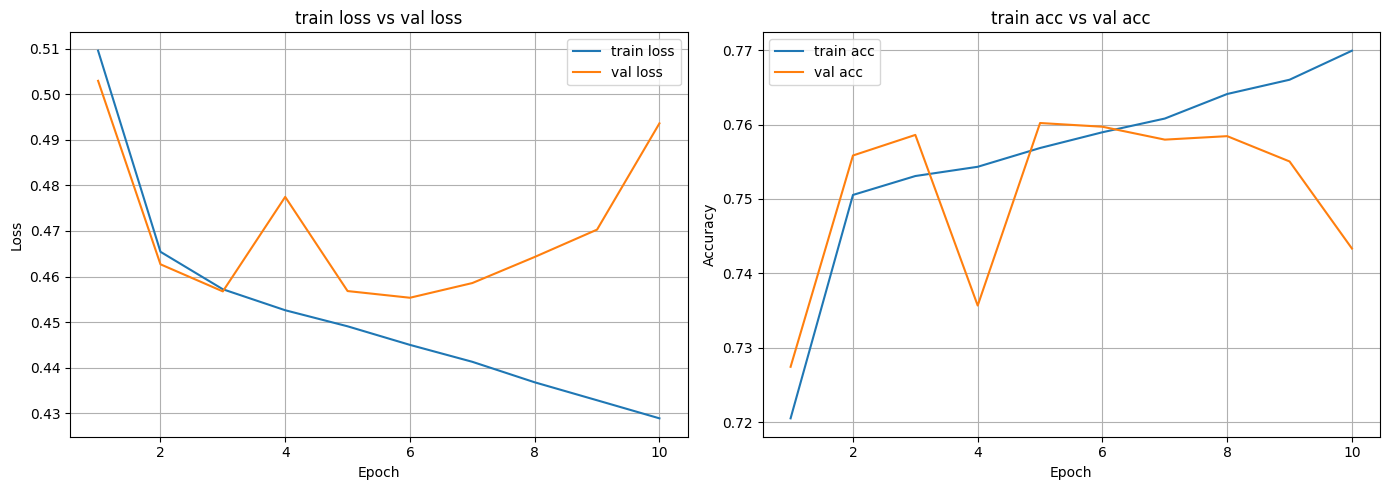

In [ ]:
epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history.history['loss'], label='train loss')
ax1.plot(epochs_range, history.history['val_loss'], label='val loss')
ax1.set_title('train loss vs val loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, history.history['accuracy'], label='train acc')
ax2.plot(epochs_range, history.history['val_accuracy'], label='val acc')
ax2.set_title('train acc vs val acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)


plt.tight_layout()
plt.show()

### (epoch = 30) 손실 곡선 & 정확도 변화 시각화

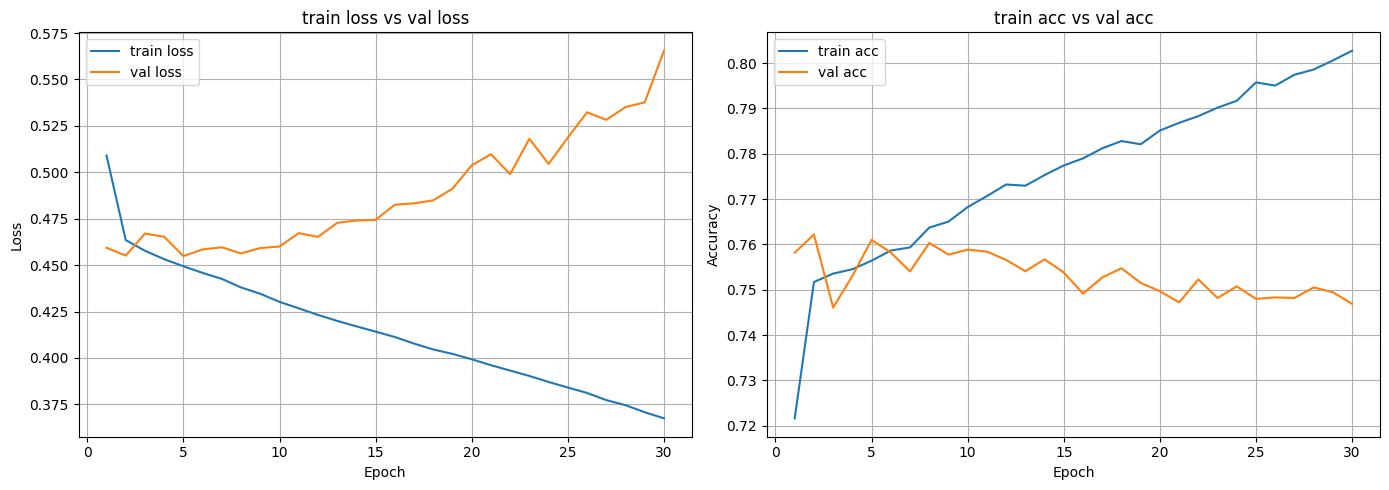

In [ ]:
epochs_range = range(1, EPOCHS_30 + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history_30.history['loss'], label='train loss')
ax1.plot(epochs_range, history_30.history['val_loss'], label='val loss')
ax1.set_title('train loss vs val loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, history_30.history['accuracy'], label='train acc')
ax2.plot(epochs_range, history_30.history['val_accuracy'], label='val acc')
ax2.set_title('train acc vs val acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)


plt.tight_layout()
plt.show()

그래프 해석: epoch 5 근처에서 val_loss가 약 0.45로 최저점을 찍고, 이후론 계속 증가. 이는 과적합이 발생한 것임. 

원인 1. 에폭수 과다 => val_loss 최저점일때 학습을 조기 종료해야 함(EarlyStopping) 

원인 2. 정규화 없음 => 각 뉴런이 훈련 데이터에 과도하게 특화되지 않도록 Dropout 레이어 추가 

원인 3. VOCAB_SIZE 작음 => 15만개의 리뷰 중 단어 2000개만 사용해, 대부분의 단어가 unk 토큰이 됨. 모델은 unknown 토큰의 패턴을 외우는 방향으로 학습하게 됨.




# week 3


In [28]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification

# KLUE 데이터셋으로 학습된 한국어 BERT
MODEL_NAME = "klue/bert-base" 


In [29]:
# 토크나이저 로드 
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample_text = "이 영화 정말 재미있다"

encoded = tokenizer(sample_text)

print(encoded)

{'input_ids': [2, 1504, 3771, 3944, 6001, 2062, 3], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}


In [ ]:
# 각 input id가 어떤 토큰과 매핑되는지 확인 
tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])
print(tokens)                                                                                                                                                                                                                         
                                                                                                                                                                                                                
for token, id in zip(tokens, encoded["input_ids"]):                                                                                                                                                                                   
    print(f"{id}\t→  {token}")        

['[CLS]', '이', '영화', '정말', '재미있', '##다', '[SEP]']
2	→  [CLS]
1504	→  이
3771	→  영화
3944	→  정말
6001	→  재미있
2062	→  ##다
3	→  [SEP]


## Fine tuning 모델 불러오기

In [41]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2 # 이진 분류 
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 21292.51it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint

In [ ]:
print(model)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(32000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,),

## 미션 2

In [6]:
!pip install sentence-transformers faiss-cpu

  Using cached scikit_learn-1.8.0-cp311-cp311-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp311-cp311-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.7/588.7 kB 11.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 12.0 MB/s  0:00:00 eta 0:00:01
Using cached scikit_learn-1.8.0-cp311-cp311-macosx_12_0_arm64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp311-cp311-macosx_14_0_arm64.whl (20.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [sentence-transformers]ence-transformers]


In [ ]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

#Knowledge base 만들기

knowledge_base = [
    "이 영화는 2023년 개봉한 한국 액션 블록버스터로 관객 800만 명을 돌파했다.",
    "주연 배우의 연기력이 뛰어나다는 평이 많으며 CG 퀄리티가 훌륭하다.",
    "스토리가 진부하고 예측 가능하다는 부정적인 의견도 존재한다.",
    "OST가 매우 감동적이며 엔딩 크레딧까지 자리를 뜨지 못하게 만든다.",
    "러닝타임이 2시간 30분으로 다소 길지만 지루하지 않다는 반응이다.",
    "아이맥스 상영관에서 보면 몰입감이 극대화된다는 관람객 후기가 많다."
]



In [19]:
# 문장을 벡터로 변환 

embedder = SentenceTransformer(
    'paraphrase-multilingual-MiniLM-L12-v2'
)

kb_embeddings = embedder.encode(
    knowledge_base,
    convert_to_numpy=True
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8685.40it/s]


In [38]:
dimension

384

In [39]:
dimension = kb_embeddings.shape[1]
print(dimension)
index = faiss.IndexFlatL2(dimension)
index.add(kb_embeddings)

384


In [15]:
def retrieve(query, top_k=2):
    query_vec = embedder.encode(
        [query],
        convert_to_numpy=True
    )

    distances, indices = index.search(
        query_vec,
        top_k
    )

    return [knowledge_base[i] for i in indices[0]]

In [ ]:
def rag_sentiment_pipeline(query):
    print(f"[질문]: {query}")

    retrieved = retrieve(query, top_k=2)
    context = " ".join(retrieved)
    print(f"[검색된 문서]: {context}")

    augmented_input = f"{context} {query}"
    result = fine_tuned_pipeline(augmented_input)[0]

    print(f"[감정 예측]: {format_result(result)}\n")
    print("-" * 60)

from transformers import pipeline
fine_tuned_pipeline = pipeline(
"text-classification",
model=model,
tokenizer=tokenizer)


def format_result(result):
    label = result["label"]
    score = result["score"]
    sentiment = "긍정" if label == "LABEL_1" else "부정"
    return f"{sentiment} (확률: {score:.4f})"
    

    

In [37]:
queries = [
    "이 영화 배우 연기가 어때요?",
    "스토리는 어떤가요?",
    "아이맥스로 볼 만한가요?"
]

for q in queries:
    rag_sentiment_pipeline(q)

[질문]: 이 영화 배우 연기가 어때요?
[검색된 문서]: 아이맥스 상영관에서 보면 몰입감이 극대화된다는 관람객 후기가 많다. 주연 배우의 연기력이 뛰어나다는 평이 많으며 CG 퀄리티가 훌륭하다.
[감정 예측]: 부정 (확률: 0.6582)

------------------------------------------------------------
[질문]: 스토리는 어떤가요?
[검색된 문서]: 아이맥스 상영관에서 보면 몰입감이 극대화된다는 관람객 후기가 많다. 스토리가 진부하고 예측 가능하다는 부정적인 의견도 존재한다.
[감정 예측]: 부정 (확률: 0.5748)

------------------------------------------------------------
[질문]: 아이맥스로 볼 만한가요?
[검색된 문서]: 아이맥스 상영관에서 보면 몰입감이 극대화된다는 관람객 후기가 많다. OST가 매우 감동적이며 엔딩 크레딧까지 자리를 뜨지 못하게 만든다.
[감정 예측]: 부정 (확률: 0.5707)

------------------------------------------------------------


# Week 4

### Step 1. NSMC 데이터 다운로드 및 데이터 구성

In [ ]:
import pandas as pd
import numpy as np
import urllib.request

# NSMC train 데이터 다운로드
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt",
    "ratings_train.txt"
)

# 데이터 로드 및 전처리
df = pd.read_csv("ratings_train.txt", sep='\t')
df = df.dropna(subset=['document'])  # 결측값 제거
df = df[df['document'].str.strip() != '']  # 빈 문장 제거

# 속도를 위해 일부 데이터만 사용 (10,000개)
df_sample = df.sample(n=10000, random_state=42).reset_index(drop=True)

# text / label 분리
texts = df_sample['document'].tolist()
labels = df_sample['label'].tolist()

print(f"총 데이터 수: {len(texts)}")
print(f"\n샘플 데이터 (앞 3개):")
for t, l in zip(texts[:3], labels[:3]):
    sentiment = "긍정" if l == 1 else "부정"
    print(f"  [{sentiment}] {t}")

총 데이터 수: 10000

샘플 데이터 (앞 3개):
  [긍정] 원본이 최고
  [긍정] 스릴감과 훈훈함이 있는 영화.
  [긍정] 굉장히 저평가되는 영화중 하나라고 생각함


### Step 2. HuggingFace 사전학습 모델 불러오기

In [2]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "klue/bert-base"

# 한국어 BERT 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# 시퀀스 분류 모델 로드 (긍정/부정 = 2 클래스)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

print(f"모델: {MODEL_NAME}")
print(f"분류 클래스 수 (num_labels): {model.config.num_labels}")
print(f"\n분류 헤드 확인:")
print(model.classifier)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


모델: klue/bert-base
분류 클래스 수 (num_labels): 2

분류 헤드 확인:
Linear(in_features=768, out_features=2, bias=True)


### Step 3. Dataset 구성하기

HuggingFace의 datasets는 데이터셋을 쉽게 로드·처리·공유할 수 있는 Python 라이브러리다. 

Trainer는 입력으로 HuggingFace Dataset 객체를 필요로 한다.
pandas DataFrame이나 일반 dict를 넘기면 오류가 발생한다. 


In [3]:
from datasets import Dataset
from sklearn.model_selection import train_test_split

# train / validation 분리 (80:20)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels  # 클래스 비율 유지
)

# HuggingFace Dataset 객체 생성
train_dataset = Dataset.from_dict({
    "text": train_texts,
    "label": train_labels
})

val_dataset = Dataset.from_dict({
    "text": val_texts,
    "label": val_labels
})

print(f"Train 데이터: {len(train_dataset)}개")
print(f"Validation 데이터: {len(val_dataset)}개")
print(f"\n데이터 구조:")
print(train_dataset)
print(f"\n샘플 데이터:")
print(train_dataset[0])

Train 데이터: 8000개
Validation 데이터: 2000개

데이터 구조:
Dataset({
    features: ['text', 'label'],
    num_rows: 8000
})

샘플 데이터:
{'text': '제목이 별로지만..의외로 정말 재밌는 멋진 사랑이야기', 'label': 1}


### Step 4. Tokenizing 함수 구현하기

In [4]:
MAX_LENGTH = 128  # 최대 토큰 길이 지정

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,       # 최대 길이 초과 시 잘라내기
        padding="max_length",  # max_length에 맞게 패딩
        max_length=MAX_LENGTH
    )

# 데이터셋 전체에 토크나이징 적용
train_tokenized = train_dataset.map(tokenize_function, batched=True)
val_tokenized = val_dataset.map(tokenize_function, batched=True)

print("토크나이징 완료!")
print(f"\n토크나이징 후 features:")
print(train_tokenized.features)
print(f"\n샘플 input_ids (앞 10개 토큰):")
print(train_tokenized[0]['input_ids'][:10])

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

토크나이징 완료!

토크나이징 후 features:
{'text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}

샘플 input_ids (앞 10개 토큰):
[2, 5772, 2052, 5429, 3683, 18, 18, 20068, 3944, 7478]


### Step 5. Fine-Tuning 학습 구성하기 / Trainer (HuggingFace)

프레임워크 : PyTorch 기반
추상화 수준 : 높음 
커스터마이징 : TrainingArguments로 설정 



In [ ]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score
import numpy as np

# 하이퍼파라미터 설정
training_args = TrainingArguments(
    output_dir="./week4_results",          # 체크포인트 저장 경로
    num_train_epochs=3,                    # 학습 에폭
    per_device_train_batch_size=16,        # 학습 배치 크기
    per_device_eval_batch_size=32,         # 평가 배치 크기
    learning_rate=2e-5,                    # 학습률
    warmup_ratio=0.1,                      # 워밍업 비율
    weight_decay=0.01,                     # 가중치 감쇠
    logging_steps=50,                      # 로그 출력 주기
    eval_strategy="epoch",                 # 에폭마다 평가
    save_strategy="epoch",                 # 에폭마다 저장
    load_best_model_at_end=True,           # 최고 성능 모델 로드
    metric_for_best_model="accuracy",      # 최적 모델 기준 metric
    report_to="none",                      # wandb 등 외부 로깅 비활성화
)

# 평가(evaluation)에 사용하는 함수
# eval_pred : Trainer가 자동으로 넘겨주는 (logits, labels) 튜플

# logits — 모델의 raw 출력값 (확률 아님)
# np.argmax(logits, axis=-1) — 가장 큰 값의 인덱스 = 예측 클래스

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc}

# Trainer 구성
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics,
)


print("학습 시작...")

trainer.train() # 이 한 줄로 배치 단위로 데이터 로드 -> 모델 예측 -> 손실 계산 -> 역전파 -> 가중치 업데이트 -> 평가 -> 체크포인트 저장까지

print("\n학습 완료!")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


학습 시작...


/opt/miniconda3/envs/gdg/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.323275,0.308268,0.871500
2,0.192473,0.353450,0.879500
3,0.148988,0.452070,0.882500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/miniconda3/envs/gdg/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/miniconda3/envs/gdg/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


학습 완료!


## Step 6. 모델 성능 평가하기

In [7]:
results = trainer.evaluate()

print("=" * 40)
print("     Validation 성능 평가 결과")
print("=" * 40)
print(f"  Loss     : {results['eval_loss']:.4f}")
print(f"  Accuracy : {results['eval_accuracy']:.4f}  ({results['eval_accuracy']*100:.2f}%)")
print("=" * 40)

/opt/miniconda3/envs/gdg/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy
0.148988,0.452070,3,0.882500


     Validation 성능 평가 결과
  Loss     : 0.4521
  Accuracy : 0.8825  (88.25%)


In [19]:
model.save_pretrained("./saved_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

저장된 모델을 불러와서 → Mac GPU에 올리고 → 추론 준비

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification


# 디바이스 설정 
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# 학습하고 저장한 모델을 불러온다
model = AutoModelForSequenceClassification.from_pretrained("./saved_model")

# 모델을 GPU(MPS)로 이동한다 
model = model.to(device)  # Move AFTER loading, not during

# 모델을 추론 모드로 전환한다 
model.eval()



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(32000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,),

## Step 7. 감정 분석 테스트 파이프라인

In [ ]:
import torch

def sentiment_pipeline(text):
    
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )
    
    # 모델과 입력 데이터가 반드시 같은 device에 있어야 함. 하나라도 다르면 RuntimeError 발생
    
    # inputs도 동일한 디바이스로 이동
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    model.to(device)  # 모델도 같은 디바이스로 이동 
    model.eval()
    
    
    
    with torch.no_grad():
        outputs = model(**inputs)
    

    probs = torch.softmax(outputs.logits, dim=-1)
    pred_idx = torch.argmax(probs, dim=-1).item()

    return {
        "text": text,
        "label": "긍정" if pred_idx == 1 else "부정",
        "score": probs[0][pred_idx].item()
    }


# 최소 3개 이상의 테스트 문장
test_sentences = [
    "이 영화 정말 재밌었어요! 배우들 연기도 너무 좋았어요.",
    "개큰붐따",
    "킬링타임용",
    "소문난 잔치에 먹을거 없다더니.. ",
    "완전 야르다."
]

print("=" * 60)
print("           감정 분석 테스트 결과")
print("=" * 60)
for sentence in test_sentences:
    result = sentiment_pipeline(sentence)
    icon = "😊" if result["label"] == "긍정" else "😞"
    print(f"\n문장: {result['text']}")
    print(f"결과: {result['label']} {icon}  (확률: {result['score']:.3f})")
print("\n" + "=" * 60)

           감정 분석 테스트 결과

문장: 이 영화 정말 재밌었어요! 배우들 연기도 너무 좋았어요.
결과: 긍정 😊  (확률: 0.998)

문장: 개큰붐따
결과: 부정 😞  (확률: 0.978)

문장: 킬링타임용
결과: 부정 😞  (확률: 0.928)

문장: 소문난 잔치에 먹을거 없다더니.. 
결과: 부정 😞  (확률: 0.997)

문장: 완전 야르다.
결과: 긍정 😊  (확률: 0.589)



### 미션 2

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
MY_MODEL_NAME = "nanahyun3/nsmc-sentiment" #본인 아이디로 설정

model.push_to_hub(MY_MODEL_NAME) #
tokenizer.push_to_hub(MY_MODEL_NAME)

print("업로드 완료!")
print(f"모델 주소: https://huggingface.co/{MY_MODEL_NAME}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

업로드 완료!
모델 주소: https://huggingface.co/nanahyun3/nsmc-sentiment


In [34]:
from huggingface_hub import HfApi

MY_MODEL_NAME = "nanahyun3/nsmc-sentiment" # 위에서 설정한 모델명으로 변경
MY_SPACE_NAME = "nanahyun3/week4" # 본인이 설정한 spacename으로 변경

# HuggingFace Hub에 업로드한 감정 분석 모델을 불러와 Gradio 웹앱으로 실행하는 코드입니다.
# Gradio UI 코드 부분은 자유롭게 구성하셔도 됩니다. 
app_code = f'''
import gradio as gr
from transformers import pipeline

classifier = pipeline("text-classification", model="{MY_MODEL_NAME}")

def format_result(result):
    label = result["label"]
    score = result["score"]

    if label == "LABEL_1":
        emoji, label_kr = "😊", "긍정"
    else:
        emoji, label_kr = "😞", "부정"

    return f"{{emoji}} {{label_kr}} (확신도: {{score:.1%}})"

def predict(text):
    if not text.strip():
        return "문장을 입력해주세요."
    result = classifier(text)[0]
    return format_result(result)

demo = gr.Interface(
    fn=predict,
    inputs=gr.Textbox(label="영화 리뷰", placeholder="리뷰를 입력하세요...", lines=3),
    outputs=gr.Textbox(label="감정 분석 결과"),
    title="AI 영화 리뷰 감정 분석기",
    description="NSMC 데이터로 파인튜닝된 한국어 감정 분석 모델입니다.",
    examples=[
        ["이 영화 진짜 재미있어요!"],
        ["완전 지루하고 별로였음"],
        ["배우 연기는 좋았지만 스토리가 아쉬웠다"]
    ]
)
demo.launch()
'''

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

with open('requirements.txt', 'w') as f:
    f.write("transformers\ngradio\ntorch\n")

# Spaces에 업로드
api = HfApi()
api.upload_file(
    path_or_fileobj="app.py",
    path_in_repo="app.py",
    repo_id=MY_SPACE_NAME,
    repo_type="space"
)
api.upload_file(
    path_or_fileobj="requirements.txt",
    path_in_repo="requirements.txt",
    repo_id=MY_SPACE_NAME,
    repo_type="space"
)

print("완료!")
print(f"https://huggingface.co/spaces/{MY_SPACE_NAME}")

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


완료!
https://huggingface.co/spaces/nanahyun3/week4
